# Лабораторна робота № 3 — нейронні мережі

Три задачі, всі на PyTorch:

1. **MLP** для табличних даних — датасет Ethereum Fraud Detection з
   лабораторної № 1; порівняння з класичними алгоритмами.
2. **CNN** для зображень — датасет **Malimg**: зображення шкідливих
   програм (кожен байт виконуваного файла — один піксель у відтінках сірого),
   25 родин. Проста CNN з нуля проти донавченої ResNet18.
3. **RNN** для текстів — описи вразливостей CVE з лабораторної № 2, класи
   критичності MEDIUM / HIGH / CRITICAL. BiLSTM з випадковими ембедингами
   проти ембедингів GloVe.

Для частин 2 і 3 потрібен GPU: у Colab — *Runtime → Change runtime type →
T4 GPU*. На CPU ноутбук теж виконається, але в рази довше.

## 0. Підготовка середовища

Клітинка створює теки `data/` та `assets/` і, якщо даних ще немає, завантажує
їх: датасети — з Kaggle через `kagglehub`, вектори GloVe — з репозиторію
gensim-data. У Colab вона також доставляє відсутні пакети.

In [1]:
import importlib.util
import shutil
import subprocess
import sys
import urllib.request
from pathlib import Path


def _in_colab():
    if "google.colab" in sys.modules:
        return True
    try:
        return importlib.util.find_spec("google.colab") is not None
    except (ImportError, ValueError):
        return False


IN_COLAB = _in_colab()

DATA = Path("data")
ASSETS = Path("assets")
CACHE = DATA / "cache"
for d in (DATA, ASSETS, CACHE):
    d.mkdir(exist_ok=True)

ETH_PATH = DATA / "ethereum-fraud.csv"
ETH_SLUG = "vagifa/ethereum-frauddetection-dataset"
CVE_SLUG = "stanislavvinokur/cve-and-cwe-dataset-1999-2025"
MALIMG_SLUG = "ikrambenabd/malimg-original"
GLOVE_URL = ("https://github.com/RaRe-Technologies/gensim-data/releases/download/"
             "glove-wiki-gigaword-100/glove-wiki-gigaword-100.gz")
GLOVE_PATH = CACHE / "glove-wiki-gigaword-100.gz"

if IN_COLAB:
    need = {"pandas": "pandas", "sklearn": "scikit-learn", "torch": "torch",
            "torchvision": "torchvision", "kagglehub": "kagglehub"}
    missing = [pkg for mod, pkg in need.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

import kagglehub

if not ETH_PATH.exists():
    root = Path(kagglehub.dataset_download(ETH_SLUG))
    shutil.copy(max(root.rglob("*.csv"), key=lambda f: f.stat().st_size), ETH_PATH)
CVE_PATH = max(Path(kagglehub.dataset_download(CVE_SLUG)).rglob("*.csv"),
               key=lambda f: f.stat().st_size)
MALIMG_DIR = next(Path(kagglehub.dataset_download(MALIMG_SLUG)).rglob("malimg_paper_dataset_imgs"))
if not GLOVE_PATH.exists():
    print("завантажую GloVe (134 МБ) ...")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_PATH)
print("дані на місці:", ETH_PATH.name, CVE_PATH.name, MALIMG_DIR.name, GLOVE_PATH.name)

дані на місці: ethereum-fraud.csv CVE_CWE_2025.csv malimg_paper_dataset_imgs glove-wiki-gigaword-100.gz


In [2]:
import copy
import gzip
import hashlib
import random
import re
import time
from collections import Counter

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC, LinearSVC
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("пристрій:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")
print("torch", torch.__version__, "| torchvision", torchvision.__version__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def save(fig, name):
    fig.savefig(ASSETS / name)
    try:
        from IPython.display import display
        display(fig)
    except ImportError:
        pass
    plt.close(fig)
    print("збережено", ASSETS / name)

пристрій: cuda NVIDIA GeForce RTX 3090
torch 2.11.0+cu128 | torchvision 0.26.0+cu128


### Спільний цикл навчання

Одна функція навчання для всіх трьох частин. Після кожної епохи рахуються
loss на навчальній і валідаційній вибірках та F1-macro на валідації. Для
оцінки на тесті береться стан моделі з **найменшим валідаційним loss** — так
тест ніяк не впливає на вибір моделі.

In [3]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total, n, preds, ys = 0.0, 0, [], []
    with torch.set_grad_enabled(train):
        for batch in loader:
            *xs, yb = [b.to(DEVICE) for b in batch]
            out = model(*xs)
            loss = loss_fn(out, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * len(yb)
            n += len(yb)
            preds.append(out.argmax(1).cpu())
            ys.append(yb.cpu())
    p, t = torch.cat(preds).numpy(), torch.cat(ys).numpy()
    return total / n, f1_score(t, p, average="macro"), accuracy_score(t, p)


def fit(model, train_loader, val_loader, epochs, lr, weight_decay=0.0, patience=None,
        verbose=True):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    hist = {k: [] for k in ("train_loss", "val_loss", "val_f1", "val_acc", "sec")}
    best, best_loss, bad = None, float("inf"), 0
    for ep in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr_loss, _, _ = run_epoch(model, train_loader, loss_fn, opt)
        va_loss, va_f1, va_acc = run_epoch(model, val_loader, loss_fn)
        for k, v in zip(hist, (tr_loss, va_loss, va_f1, va_acc, time.perf_counter() - t0)):
            hist[k].append(v)
        if va_loss < best_loss:
            best_loss, best, bad = va_loss, copy.deepcopy(model.state_dict()), 0
            hist["best_epoch"] = ep
        else:
            bad += 1
        if verbose and (ep == 1 or ep % max(1, epochs // 10) == 0 or ep == epochs):
            print(f"  епоха {ep:>3}: train {tr_loss:.4f}  val {va_loss:.4f}  "
                  f"val F1 {va_f1:.4f}  ({hist['sec'][-1]:.1f} с)")
        if patience and bad >= patience:
            if verbose:
                print(f"  рання зупинка на епосі {ep}: val loss не покращувався {patience} епох")
            break
    hist["last_state"] = copy.deepcopy(model.state_dict())
    model.load_state_dict(best)
    return hist


@torch.no_grad()
def predict(model, loader):
    model.eval()
    return torch.cat([model(*[b.to(DEVICE) for b in batch[:-1]]).argmax(1).cpu()
                      for batch in loader]).numpy()


def plot_curves(hists, title, name, ylim=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    for (label, h), color in zip(hists.items(), sns.color_palette("tab10")):
        ep = np.arange(1, len(h["train_loss"]) + 1)
        axes[0].plot(ep, h["train_loss"], color=color, ls="--", label=f"{label}: train")
        axes[0].plot(ep, h["val_loss"], color=color, label=f"{label}: validation")
        axes[0].axvline(h["best_epoch"], color=color, ls=":", lw=1)
        axes[1].plot(ep, h["val_f1"], color=color, label=label)
    axes[0].set_title(f"{title}: loss"); axes[0].set_ylabel("cross-entropy")
    axes[1].set_title(f"{title}: F1-macro на валідації"); axes[1].set_ylabel("F1-macro")
    if ylim:
        axes[0].set_ylim(*ylim)
    for ax in axes:
        ax.set_xlabel("епоха"); ax.legend(fontsize=7)
    fig.tight_layout()
    save(fig, name)

## 1. Повнозв'язана нейронна мережа (MLP)

### 1.1. Дані

Підготовка — як у лабораторній № 1: службові колонки, через які протікала
мітка, і константні колонки прибрано; пропуски заповнено медіаною,
категоріальні ознаки закодовано one-hot, числові стандартизовано. Тестова
вибірка — та сама (25 %, стратифікований поділ, `random_state = 42`), тож
результати напряму порівнянні з лабораторною № 1. З навчальної частини
додатково відкладено 15 % на валідацію — для learning curves і вибору епохи.

In [4]:
TARGET = "FLAG"
eth = pd.read_csv(ETH_PATH)
eth.columns = [c.strip() for c in eth.columns]
eth = eth.drop(columns=["Unnamed: 0", "Index", "Address"])
_num = eth.drop(columns=[TARGET]).select_dtypes(include=[np.number])
eth = eth.drop(columns=[c for c in _num.columns if _num[c].nunique(dropna=True) <= 1])
NUM_COLS = eth.drop(columns=[TARGET]).select_dtypes(include=[np.number]).columns.tolist()
CAT_COLS = eth.drop(columns=[TARGET]).select_dtypes(exclude=[np.number]).columns.tolist()

X, y = eth.drop(columns=[TARGET]), eth[TARGET]
X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_tr_full, y_tr_full, test_size=0.15, random_state=RANDOM_STATE, stratify=y_tr_full)


def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), NUM_COLS),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                max_categories=11, sparse_output=False))]),
         CAT_COLS),
    ])


pre = make_preprocessor().fit(X_tr)
to_t = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)
Xt_tr, Xt_va, Xt_te = (to_t(pre.transform(d)) for d in (X_tr, X_va, X_te))
yt_tr, yt_va, yt_te = (torch.tensor(v.to_numpy()) for v in (y_tr, y_va, y_te))
N_IN = Xt_tr.shape[1]
print(f"train {len(Xt_tr)}, validation {len(Xt_va)}, test {len(Xt_te)}; ознак: {N_IN}")

tab_loaders = lambda bs: (DataLoader(TensorDataset(Xt_tr, yt_tr), batch_size=bs, shuffle=True),
                          DataLoader(TensorDataset(Xt_va, yt_va), batch_size=1024),
                          DataLoader(TensorDataset(Xt_te, yt_te), batch_size=1024))

train 6273, validation 1107, test 2461; ознак: 60


### 1.2. Архітектура та навчання

MLP: 60 → 256 → 128 → 2, активація ReLU. Навчено два варіанти:

* **без регуляризації** — 200 епох, щоб побачити, як поводиться модель,
  якій нічого не заважає підлаштовуватися під навчальну вибірку;
* **з регуляризацією** — dropout 0.3, L2-регуляризація (`weight_decay`) і
  рання зупинка, якщо валідаційний loss не покращується 20 епох.

параметрів: 48,770
MLP без регуляризації:


  епоха   1: train 0.4757  val 0.2906  val F1 0.8773  (0.3 с)


  епоха  20: train 0.0170  val 0.0558  val F1 0.9881  (0.1 с)


  епоха  40: train 0.0096  val 0.0812  val F1 0.9882  (0.2 с)


  епоха  60: train 0.0072  val 0.1115  val F1 0.9882  (0.1 с)


...

  епоха 160: train 0.0026  val 0.2388  val F1 0.9882  (0.2 с)


  епоха 180: train 0.0014  val 0.2692  val F1 0.9882  (0.2 с)


  епоха 200: train 0.0109  val 0.2528  val F1 0.9882  (0.2 с)
MLP з регуляризацією:
  епоха   1: train 0.4861  val 0.3207  val F1 0.7025  (0.2 с)


  епоха  20: train 0.0245  val 0.0585  val F1 0.9829  (0.2 с)


  рання зупинка на епосі 39: val loss не покращувався 20 епох


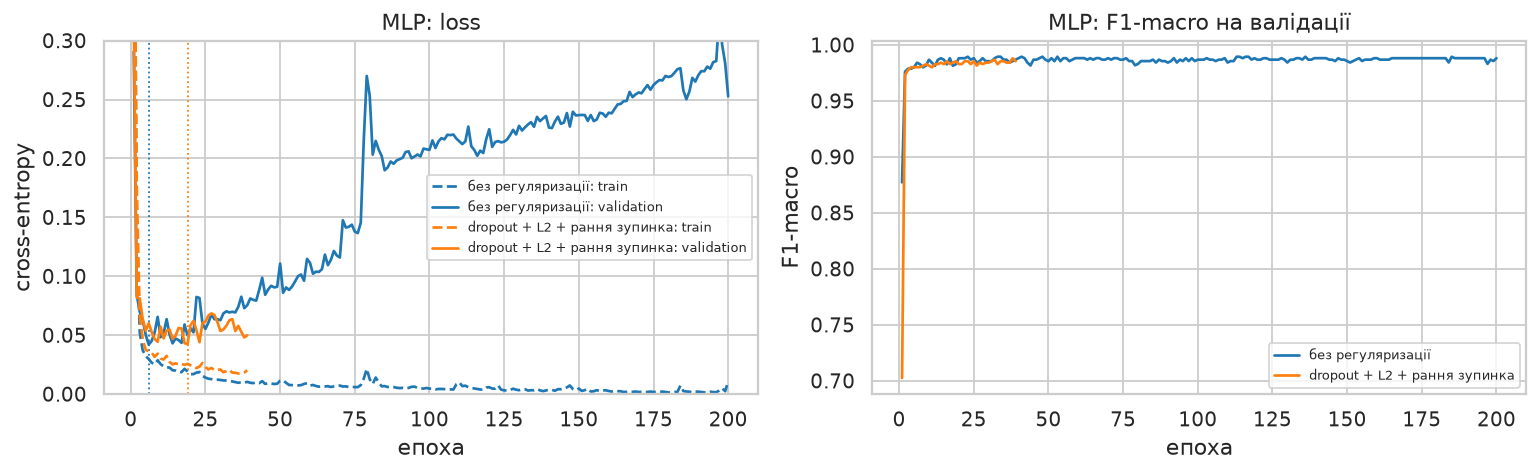

збережено assets/01-mlp-curves.png


In [5]:
class MLP(nn.Module):
    def __init__(self, n_in, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 2))

    def forward(self, x):
        return self.net(x)


print(f"параметрів: {sum(p.numel() for p in MLP(N_IN).parameters()):,}")
tr_l, va_l, te_l = tab_loaders(256)

set_seed()
print("MLP без регуляризації:")
mlp_plain = MLP(N_IN)
h_plain = fit(mlp_plain, tr_l, va_l, epochs=200, lr=1e-3)

set_seed()
print("MLP з регуляризацією:")
mlp_reg = MLP(N_IN, dropout=0.3)
h_reg = fit(mlp_reg, tr_l, va_l, epochs=200, lr=1e-3, weight_decay=1e-4, patience=20)

plot_curves({"без регуляризації": h_plain, "dropout + L2 + рання зупинка": h_reg},
            "MLP", "01-mlp-curves.png", ylim=(0, 0.3))

In [6]:
def mlp_eval(model, state=None):
    m = copy.deepcopy(model)
    if state is not None:
        m.load_state_dict(state)
    p = predict(m, te_l)
    return accuracy_score(yt_te, p), f1_score(yt_te, p, average="macro")


rows = []
for name, model, h in (("MLP без регуляризації", mlp_plain, h_plain),
                       ("MLP з регуляризацією", mlp_reg, h_reg)):
    acc, f1 = mlp_eval(model)
    rows.append({"модель": name, "стан": f"найкраща епоха ({h['best_epoch']})",
                 "accuracy": acc, "f1_macro": f1})
acc, f1 = mlp_eval(mlp_plain, h_plain["last_state"])
rows.append({"модель": "MLP без регуляризації", "стан": "остання епоха (200)",
             "accuracy": acc, "f1_macro": f1})
mlp_res = pd.DataFrame(rows)
print(mlp_res.round(4).to_string(index=False))
i_min = int(np.argmin(h_plain["val_loss"]))
print(f"\nБез регуляризації: мінімум val loss {h_plain['val_loss'][i_min]:.4f} на епосі {i_min + 1}, "
      f"на епосі 200 — {h_plain['val_loss'][-1]:.4f}; train loss на епосі 200 — "
      f"{h_plain['train_loss'][-1]:.5f}")

               модель                стан  accuracy  f1_macro
MLP без регуляризації  найкраща епоха (6)    0.9870    0.9808
 MLP з регуляризацією найкраща епоха (19)    0.9874    0.9814
MLP без регуляризації остання епоха (200)    0.9878    0.9823

Без регуляризації: мінімум val loss 0.0420 на епосі 6, на епосі 200 — 0.2528; train loss на епосі 200 — 0.01095


**Чи спостерігається перенавчання?** Так, і learning curves показують його
класично: без регуляризації валідаційний loss досягає мінімуму (0.042) уже на
**6-й епосі**, а далі зростає — до 0.253 на 200-й, тоді як навчальний падає
майже до нуля (0.011). Мережа з 48 770 параметрами на 6 273 прикладах
поступово запам'ятовує навчальну вибірку.

Але є важлива деталь: валідаційний **F1 при цьому не падає** — він тримається
близько 0.988 усі 200 епох, а модель з останньої епохи на тесті навіть трохи
краща (0.9823), ніж модель з мінімумом loss (0.9808). Перенавчання тут
проявляється не в рішеннях, а в **упевненості**: на кількох прикладах, де
мережа помиляється, вона помиляється дедалі впевненіше, а cross-entropy
штрафує впевнені помилки дуже сильно. Для класифікації за `argmax` це майже
нешкідливо, для задач, де потрібні ймовірності (скоринг ризику), — ні.

Dropout 0.3, L2-регуляризація та рання зупинка (на 39-й епосі) прибирають
зростання loss: криві train і validation лишаються поруч, а якість та сама
(F1 = 0.9814).

### 1.3. Порівняння з класичними алгоритмами

Класичні моделі з лабораторної № 1 перенавчено тут на тих самих даних, тим
самим препроцесингом і з тими самими параметрами. Вони бачать повну
навчальну частину (без валідаційних 15 %), як і в лабораторній № 1.

               модель  accuracy  f1_macro
             AdaBoost    0.9935    0.9905
        Random Forest    0.9919    0.9881
SVM (C=1000, γ=0.001)    0.9874    0.9815
 MLP з регуляризацією    0.9874    0.9814
MLP без регуляризації    0.9870    0.9808


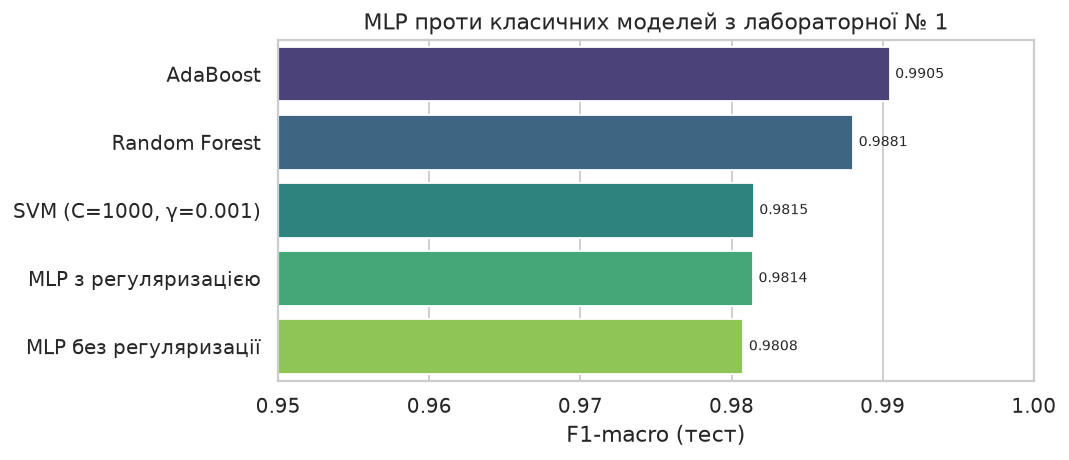

збережено assets/02-mlp-vs-classic.png


In [7]:
classic = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "SVM (C=1000, γ=0.001)": SVC(C=1000, gamma=0.001, random_state=RANDOM_STATE),
}
cls_rows = []
for name, model in classic.items():
    pipe = Pipeline([("pre", make_preprocessor()), ("model", model)]).fit(X_tr_full, y_tr_full)
    p = pipe.predict(X_te)
    cls_rows.append({"модель": name, "accuracy": accuracy_score(y_te, p),
                     "f1_macro": f1_score(y_te, p, average="macro")})
compare = pd.concat([pd.DataFrame(cls_rows),
                     mlp_res[mlp_res["стан"].str.startswith("найкраща")][["модель", "accuracy", "f1_macro"]]],
                    ignore_index=True).sort_values("f1_macro", ascending=False)
compare.round(4).to_csv(DATA / "mlp-vs-classic.csv", index=False)
print(compare.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
sns.barplot(data=compare, y="модель", x="f1_macro", hue="модель", legend=False,
            palette="viridis", ax=ax)
ax.set_xlim(0.95, 1.0)
ax.set_xlabel("F1-macro (тест)"); ax.set_ylabel("")
ax.set_title("MLP проти класичних моделей з лабораторної № 1")
for c in ax.containers:
    ax.bar_label(c, fmt="%.4f", fontsize=8, padding=3)
save(fig, "02-mlp-vs-classic.png")

MLP (0.9814) опиняється на рівні SVM (0.9815) і поступається ансамблям дерев:
AdaBoost — 0.9905, Random Forest — 0.9881. Для табличних даних це типова
картина. Ознаки тут неоднорідні й з важкими хвостами, а залежність від них
порогова: «акаунт прожив менше доби», «ERC20-даних немає». Дерева виражають
такі правила напряму одним розщепленням, а нейромережа мусить наближати
порогову функцію гладкими. До того ж 6 тис. прикладів — замало, щоб перевага
нейромереж у гнучкості переважила їхню вимогливість до даних. Нейромережа не
дала виграшу ні в якості, ні в зусиллях: її довелося регуляризувати,
а Random Forest працює «з коробки».

## 2. Згорткові нейронні мережі: Malimg

### 2.1. Датасет

Malimg (Nataraj et al., 2011) — 9 339 зразків шкідливих програм із 25 родин.
Кожен виконуваний файл перетворено на зображення: байти читаються підряд і
розкладаються рядками фіксованої ширини, значення байта (0–255) — яскравість
пікселя. Різні секції файла (код, дані, ресурси) мають різну статистику
байтів, тому на зображенні вони видно як області з різною текстурою, а
варіанти однієї родини, зібрані з одного коду, мають схожий візерунок.

In [8]:
files = sorted(MALIMG_DIR.rglob("*.png"))
fam_all = Counter(f.parent.name for f in files)
seen, keep = set(), []
for f in files:
    h = hashlib.md5(f.read_bytes()).hexdigest()
    if h not in seen:
        seen.add(h)
        keep.append(f)
fam = Counter(f.parent.name for f in keep)
CLASSES = sorted(fam)
counts = pd.DataFrame({"усього файлів": pd.Series(fam_all), "унікальних": pd.Series(fam)})
counts["дублікатів"] = counts["усього файлів"] - counts["унікальних"]
counts = counts.sort_values("унікальних", ascending=False)
print(f"Файлів: {len(files)}, унікальних: {len(keep)}, точних дублікатів: {len(files) - len(keep)}")
print(f"Класів: {len(CLASSES)}; найбільший — {counts.index[0]} ({counts.iloc[0, 1]}), "
      f"найменший — {counts.index[-1]} ({counts.iloc[-1, 1]})")
print(counts.to_string())
widths = Counter(Image.open(f).size[0] for f in keep)
print("\nШирина зображень:", dict(sorted(widths.items())))

Файлів: 9339, унікальних: 8444, точних дублікатів: 895
Класів: 25; найбільший — Allaple.A (2949), найменший — Skintrim.N (80)
                усього файлів  унікальних  дублікатів
Allaple.A                2949        2949           0
Allaple.L                1591        1591           0
Instantaccess             431         431           0
VB.AT                     408         408           0
Lolyda.AA1                213         213           0
C2LOP.gen!g               200         200           0
Fakerean                  381         199         182
Alueron.gen!J             198         198           0
Lolyda.AA2                184         184           0
Dialplatform.B            177         177           0
Dontovo.A                 162         162           0
Rbot!gen                  158         158           0
Lolyda.AT                 159         157           2
C2LOP.P                   146         146           0
Obfuscator.AD             142         142           0
Malex.gen!


Ширина зображень: {64: 699, 128: 1901, 256: 3209, 384: 934, 512: 1042, 768: 642, 1024: 17}


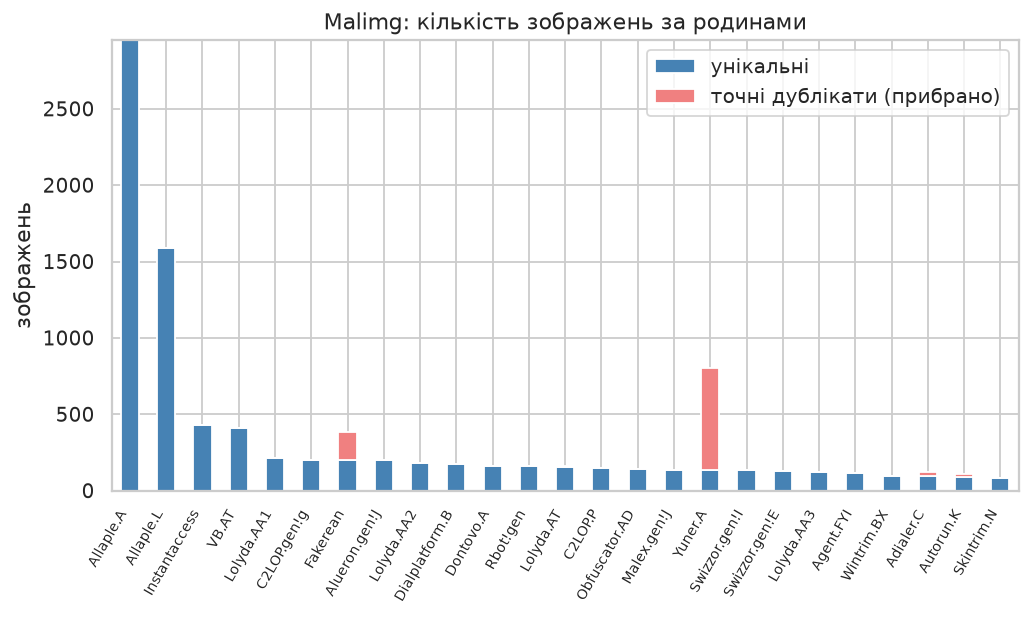

збережено assets/03-malimg-counts.png


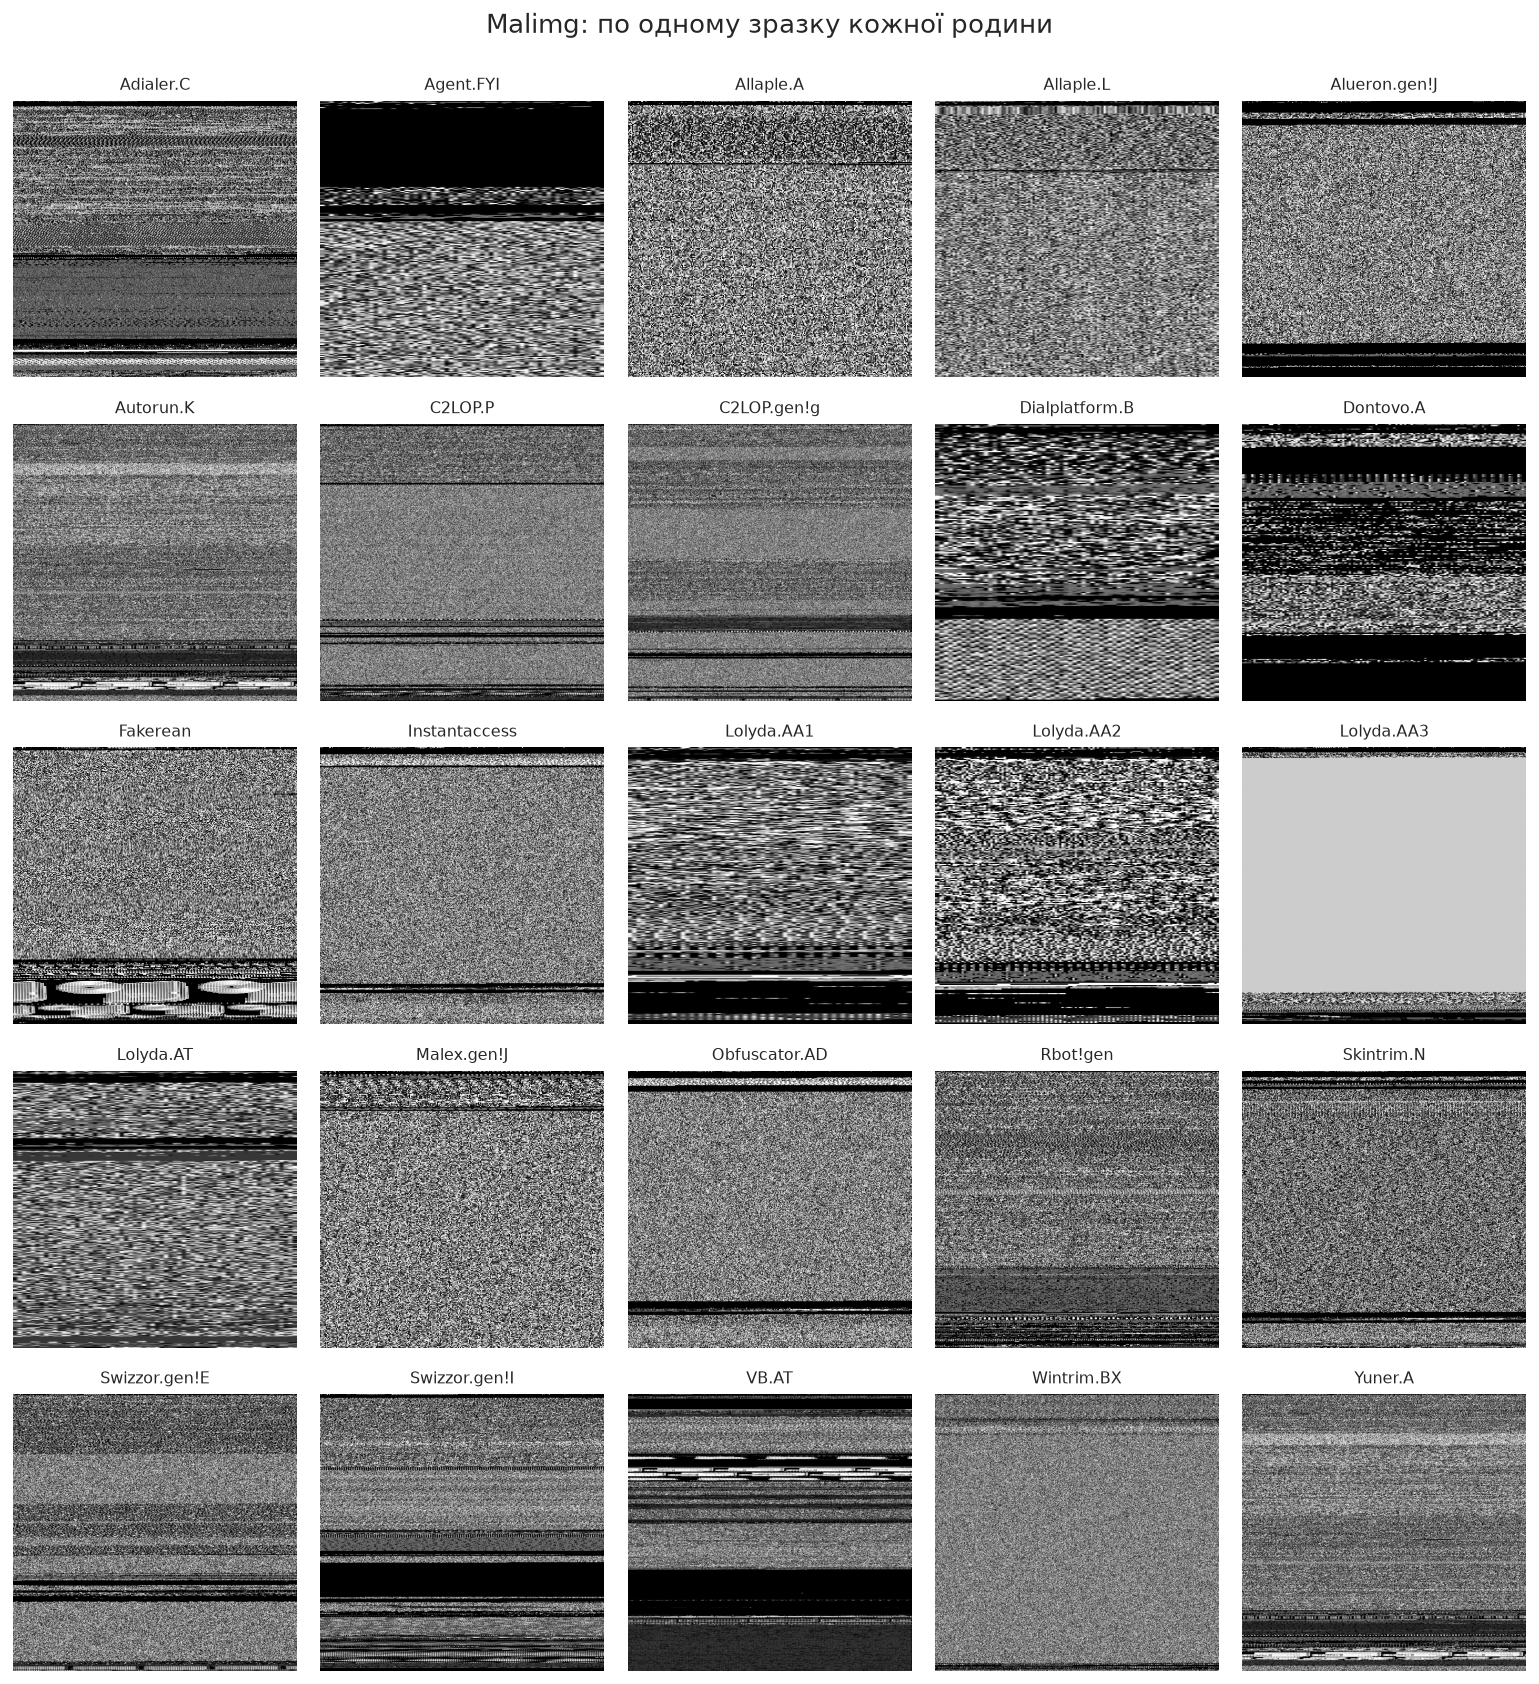

збережено assets/04-malimg-examples.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
counts["унікальних"].plot(kind="bar", ax=ax, color="steelblue", label="унікальні")
counts["дублікатів"].plot(kind="bar", ax=ax, bottom=counts["унікальних"], color="lightcoral",
                          label="точні дублікати (прибрано)")
ax.set_ylabel("зображень"); ax.set_title("Malimg: кількість зображень за родинами")
ax.legend(); plt.setp(ax.get_xticklabels(), rotation=60, ha="right", fontsize=8)
save(fig, "03-malimg-counts.png")

fig, axes = plt.subplots(5, 5, figsize=(12, 13))
for ax, c in zip(axes.ravel(), CLASSES):
    f = next(f for f in keep if f.parent.name == c)
    ax.imshow(Image.open(f), cmap="gray", aspect="auto")
    ax.set_title(c, fontsize=9); ax.axis("off")
fig.suptitle("Malimg: по одному зразку кожної родини", y=0.995)
fig.tight_layout()
save(fig, "04-malimg-examples.png")

Датасет сильно незбалансований: найбільша родина (Allaple.A, 2 949 зразків) у
37 разів більша за найменшу (Skintrim.N, 80). Ще важливіше — **895 точних
дублікатів** (9.6 %), і вони зосереджені в кількох родинах: у Yuner.A з 800
файлів унікальних лише 133 (83 % — копії), у Fakerean — 199 з 381. Без
дедуплікації Yuner.A виглядала б третьою за розміром родиною, а її
«розпізнавання» зводилося б до впізнавання копій, що потрапили і в навчальну,
і в тестову вибірку.

На прикладах видно, що зображення справді мають структуру: горизонтальні
смуги — секції виконуваного файла, а текстура в них залежить від вмісту.
Стиснені чи зашифровані ділянки виглядають як шум, таблиці й вирівнювання
нулями — як рівні однотонні області.

### 2.2. Підготовка зображень

Точні дублікати прибрано **до** поділу на вибірки, інакше та сама картинка
потрапила б і в навчальну, і в тестову вибірку, завищивши оцінку. Зображення
мають різний розмір (ширина 64–1024 пікселі, висота залежить від розміру
файла), тож усі зведено до 128 × 128. Обидві моделі отримують однаковий вхід —
інакше порівняння залежало б від роздільності, а не від архітектури.
Аугментацію (віддзеркалення, повороти) не застосовано: це послідовність
байтів, розкладена рядками, і віддзеркалений файл — уже інший файл.

In [10]:
IMG = 128
labels_img = np.array([CLASSES.index(f.parent.name) for f in keep])
images = np.stack([np.asarray(Image.open(f).convert("L").resize((IMG, IMG), Image.BILINEAR))
                   for f in keep])
idx = np.arange(len(keep))
i_tr, i_tmp = train_test_split(idx, test_size=0.30, random_state=RANDOM_STATE, stratify=labels_img)
i_va, i_te = train_test_split(i_tmp, test_size=0.50, random_state=RANDOM_STATE,
                              stratify=labels_img[i_tmp])
print(f"train {len(i_tr)}, validation {len(i_va)}, test {len(i_te)}")

IMG_T = torch.tensor(images, dtype=torch.float32).unsqueeze(1) / 255.0
LAB_T = torch.tensor(labels_img)


def img_loader(ids, shuffle=False, bs=64):
    return DataLoader(TensorDataset(IMG_T[ids], LAB_T[ids]), batch_size=bs, shuffle=shuffle)

train 5910, validation 1267, test 1267


### 2.3. Моделі

**Проста CNN з нуля**: три згорткові блоки (згортка 3 × 3, batch
normalization, ReLU, max-pooling), далі глобальне усереднення й один
повнозв'язаний шар на 25 класів.

**Pretrained ResNet18** з вагами ImageNet: останній шар (`fc`, 1000 класів)
замінено на новий на 25 класів, донавчається вся мережа з малою швидкістю
навчання. ResNet очікує три канали й нормалізацію ImageNet, тож сірий канал
повторюється тричі і нормалізується всередині моделі.

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(1, 32), block(32, 64), block(64, 128))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(128, n_classes))

    def forward(self, x):
        return self.head(self.features(x))


class PretrainedResNet(nn.Module):
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def __init__(self, n_classes):
        super().__init__()
        self.net = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        self.net.fc = nn.Linear(self.net.fc.in_features, n_classes)
        self.register_buffer("mean", self.MEAN)
        self.register_buffer("std", self.STD)

    def forward(self, x):
        return self.net((x.repeat(1, 3, 1, 1) - self.mean) / self.std)


n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"SimpleCNN: {n_params(SimpleCNN(25)):,} параметрів; "
      f"ResNet18: {n_params(PretrainedResNet(25)):,} параметрів")

CNN_EPOCHS = {"CNN з нуля": 30, "ResNet18 (pretrained)": 15}
CNN_LR = {"CNN з нуля": 1e-3, "ResNet18 (pretrained)": 1e-4}
CNN_CLS = {"CNN з нуля": SimpleCNN, "ResNet18 (pretrained)": PretrainedResNet}

SimpleCNN: 96,345 параметрів; ResNet18: 11,189,337 параметрів


CNN з нуля:


  епоха   1: train 1.2112  val 0.7674  val F1 0.4755  (2.0 с)


  епоха   3: train 0.3950  val 0.4258  val F1 0.8166  (1.7 с)


  епоха   6: train 0.1787  val 0.1396  val F1 0.8710  (1.6 с)


  епоха   9: train 0.1226  val 0.0900  val F1 0.8891  (1.6 с)


...

  епоха  11: train 0.0185  val 0.0627  val F1 0.9192  (2.5 с)


  епоха  12: train 0.0076  val 0.0416  val F1 0.9758  (2.8 с)


  епоха  13: train 0.0008  val 0.0421  val F1 0.9779  (2.9 с)


  епоха  14: train 0.0005  val 0.0433  val F1 0.9758  (2.3 с)


  епоха  15: train 0.0004  val 0.0439  val F1 0.9758  (2.3 с)


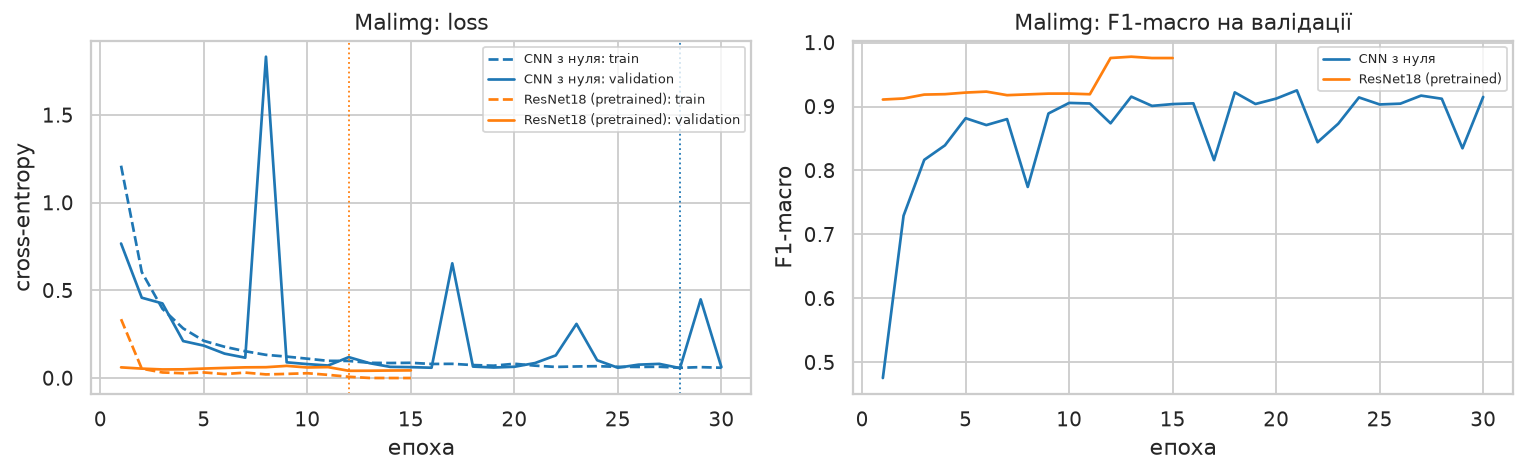

збережено assets/05-cnn-curves.png


In [12]:
cnn_hist, cnn_models = {}, {}
va_img, te_img = img_loader(i_va), img_loader(i_te)
for name in CNN_CLS:
    set_seed()
    print(f"{name}:")
    m = CNN_CLS[name](len(CLASSES))
    cnn_hist[name] = fit(m, img_loader(i_tr, shuffle=True), va_img,
                         epochs=CNN_EPOCHS[name], lr=CNN_LR[name])
    cnn_models[name] = m
plot_curves(cnn_hist, "Malimg", "05-cnn-curves.png")

Криві навчання двох моделей різняться принципово:

- **CNN з нуля** починає практично з нуля (F1 = 0.48 після першої епохи),
  досягає 0.90 лише на 10-й епосі й далі коливається. Валідаційний loss має
  різкі сплески (до 1.8 на 8-й епосі): мала мережа з batch normalization
  чутлива до складу окремих батчів, і кожна епоха помітно зсуває межі класів.
- **ResNet18** уже після **першої** епохи має F1 = 0.91 — майже стільки ж,
  скільки CNN з нуля в найкращій з 30 епох (0.925). Ознаки, навчені на ImageNet (краї, текстури, періодичні
  візерунки), придатні й для текстур бінарних файлів, тож донавчання лише
  підлаштовує їх. Криві гладкі, розрив між train і validation малий.

У ResNet18 є характерне плато: 11 епох валідаційний F1 тримається близько
0.92, а на 12-й стрибає до 0.976. Імовірно, саме тоді мережа починає
розрізняти близькі варіанти однієї родини: як видно з матриці похибок нижче,
саме між ними лишаються майже всі помилки.

In [13]:
cnn_rows = []
for name, m in cnn_models.items():
    h = cnn_hist[name]
    p = predict(m, te_img)
    f1s = np.array(h["val_f1"])
    reach = int(np.argmax(f1s >= 0.90)) + 1 if (f1s >= 0.90).any() else None
    cnn_rows.append({"модель": name, "accuracy": accuracy_score(LAB_T[i_te], p),
                     "f1_macro": f1_score(LAB_T[i_te], p, average="macro"),
                     "найкраща епоха": h["best_epoch"],
                     "перша епоха з val F1 ≥ 0.90": reach,
                     "val F1 після 1-ї епохи": f1s[0],
                     "с/епоха": float(np.mean(h["sec"]))})
cnn_res = pd.DataFrame(cnn_rows)
cnn_res.round(4).to_csv(DATA / "cnn-results.csv", index=False)
print(cnn_res.round(4).to_string(index=False))

               модель  accuracy  f1_macro  найкраща епоха  перша епоха з val F1 ≥ 0.90  val F1 після 1-ї епохи  с/епоха
           CNN з нуля    0.9692    0.8959              28                           10                  0.4755   1.6058
ResNet18 (pretrained)    0.9929    0.9842              12                            1                  0.9109   2.4432


Один запуск не показує, наскільки результат стійкий, тож обидві моделі
навчено ще з двома seed на повних даних.

In [14]:
seed_rows = []
for name in CNN_CLS:
    for seed in (42, 7, 2026):
        if seed == 42:
            m, h = cnn_models[name], cnn_hist[name]
        else:
            set_seed(seed)
            m = CNN_CLS[name](len(CLASSES))
            h = fit(m, img_loader(i_tr, shuffle=True), va_img, epochs=CNN_EPOCHS[name],
                    lr=CNN_LR[name], verbose=False)
        p = predict(m, te_img)
        seed_rows.append({"модель": name, "seed": seed,
                          "f1_macro": f1_score(LAB_T[i_te], p, average="macro"),
                          "accuracy": accuracy_score(LAB_T[i_te], p),
                          "найкраща епоха": h["best_epoch"],
                          "макс. val F1": max(h["val_f1"])})
cnn_seeds = pd.DataFrame(seed_rows)
cnn_seeds.round(4).to_csv(DATA / "cnn-seeds.csv", index=False)
print(cnn_seeds.round(4).to_string(index=False))
print()
print(cnn_seeds.groupby("модель", sort=False)[["f1_macro", "accuracy"]]
      .agg(["mean", "std"]).round(4).to_string())

               модель  seed  f1_macro  accuracy  найкраща епоха  макс. val F1
           CNN з нуля    42    0.8959    0.9692              28        0.9253
           CNN з нуля     7    0.9249    0.9787              27        0.9287
           CNN з нуля  2026    0.8961    0.9708              25        0.9229
ResNet18 (pretrained)    42    0.9842    0.9929              12        0.9779
ResNet18 (pretrained)     7    0.9818    0.9921              15        0.9799
ResNet18 (pretrained)  2026    0.9829    0.9929               9        0.9790

                      f1_macro         accuracy        
                          mean     std     mean     std
модель                                                 
CNN з нуля              0.9056  0.0167   0.9729  0.0051
ResNet18 (pretrained)   0.9830  0.0012   0.9926  0.0005


Перевага pretrained-моделі стійка: за трьома seed ResNet18 дає F1 =
0.9830 ± 0.0012, CNN з нуля — 0.9056 ± 0.0167. Стрибок після плато стався в
усіх трьох запусках (максимальний валідаційний F1 — 0.978–0.980). Розкид у CNN
з нуля в 14 разів більший, тобто вона не лише гірша, а й менш стабільна.

Accuracy обох моделей помітно вища за F1-macro (0.993 проти 0.983 у ResNet18):
помилки зосереджені в малих класах, а macro-усереднення дає кожному класу
однакову вагу незалежно від розміру.

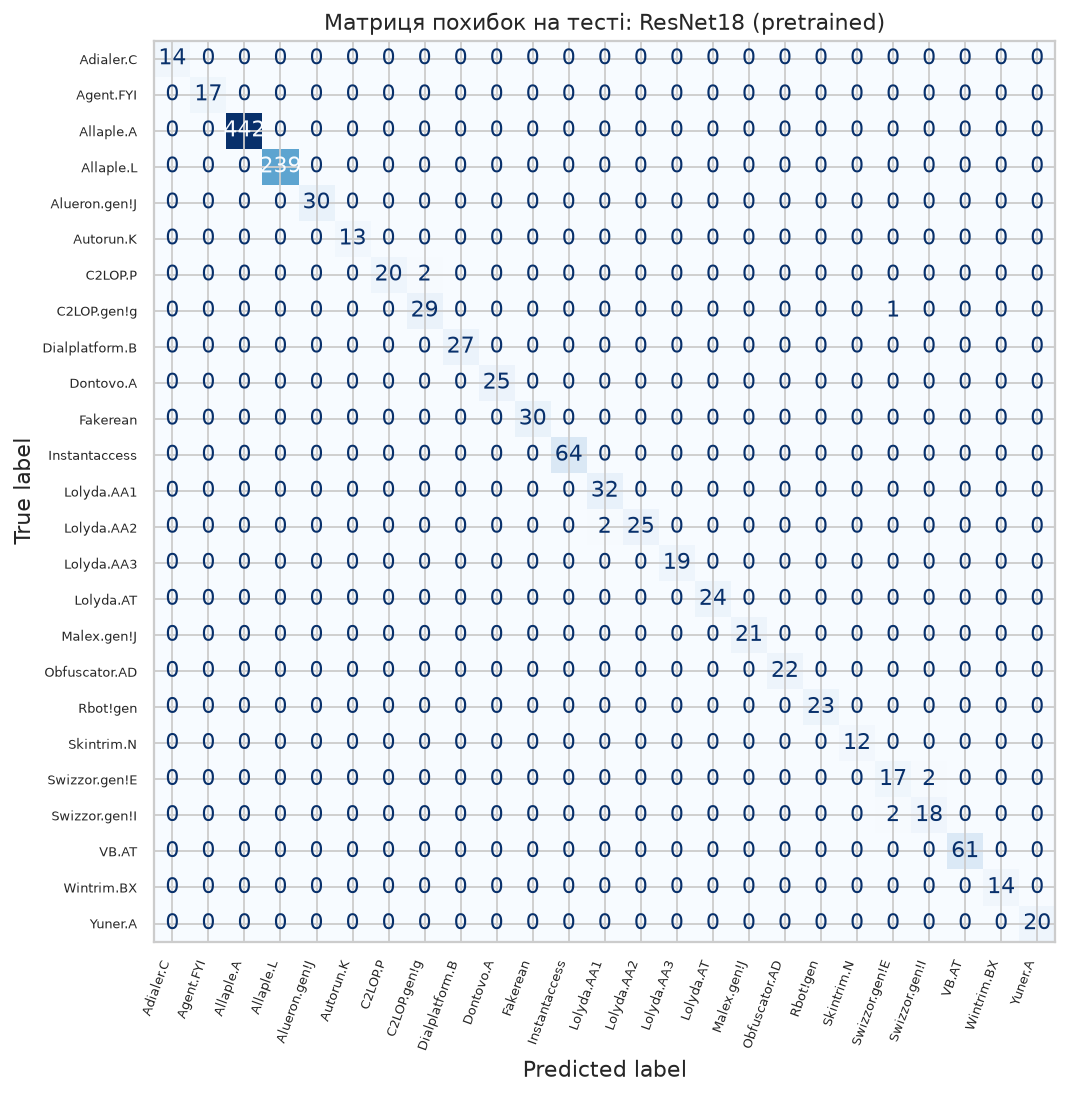

збережено assets/06-cnn-confusion.png
Усі помилки (істинна → передбачена):
           C2LOP.P → C2LOP.gen!g      2
        Lolyda.AA2 → Lolyda.AA1       2
     Swizzor.gen!E → Swizzor.gen!I    2
     Swizzor.gen!I → Swizzor.gen!E    2
       C2LOP.gen!g → Swizzor.gen!E    1


In [15]:
best_cnn = cnn_res.sort_values("f1_macro").iloc[-1]["модель"]
p = predict(cnn_models[best_cnn], te_img)
cm = confusion_matrix(LAB_T[i_te], p, labels=range(len(CLASSES)))
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False,
                                                        values_format="d")
plt.setp(ax.get_xticklabels(), rotation=70, ha="right", fontsize=7)
plt.setp(ax.get_yticklabels(), fontsize=7)
ax.set_title(f"Матриця похибок на тесті: {best_cnn}")
save(fig, "06-cnn-confusion.png")
errs = [(CLASSES[i], CLASSES[j], int(cm[i, j])) for i in range(len(CLASSES))
        for j in range(len(CLASSES)) if i != j and cm[i, j] > 0]
print("Усі помилки (істинна → передбачена):")
for a, b, n in sorted(errs, key=lambda e: -e[2]):
    print(f"  {a:>16} → {b:<16} {n}")

На тесті з 1 267 зображень ResNet18 помиляється лише 9 разів, і 8 із цих
помилок — між **варіантами однієї родини**: C2LOP.P і C2LOP.gen!g,
Lolyda.AA2 і Lolyda.AA1, Swizzor.gen!E і Swizzor.gen!I. Такі варіанти зібрані
з майже того самого коду, тож їхні зображення майже збігаються — це межа
того, що взагалі можна розрізнити за виглядом файла. Лише одна помилка
перетинає межу родин (C2LOP.gen!g → Swizzor.gen!E).

### 2.4. Вплив обсягу навчальних даних

Обидві моделі навчено наново на частках навчальної вибірки — від 5 % до
100 % (стратифіковано, тобто кожна родина представлена пропорційно).
Валідаційна й тестова вибірки не змінюються.

     5% ( 295 зобр.)  CNN з нуля             F1 0.5611


     5% ( 295 зобр.)  ResNet18 (pretrained)  F1 0.8713


    10% ( 591 зобр.)  CNN з нуля             F1 0.8200


    10% ( 591 зобр.)  ResNet18 (pretrained)  F1 0.9021


    25% (1477 зобр.)  CNN з нуля             F1 0.8470


    25% (1477 зобр.)  ResNet18 (pretrained)  F1 0.9144


    50% (2955 зобр.)  CNN з нуля             F1 0.9002


    50% (2955 зобр.)  ResNet18 (pretrained)  F1 0.9211


   100% (5910 зобр.)  CNN з нуля             F1 0.8959


   100% (5910 зобр.)  ResNet18 (pretrained)  F1 0.9842


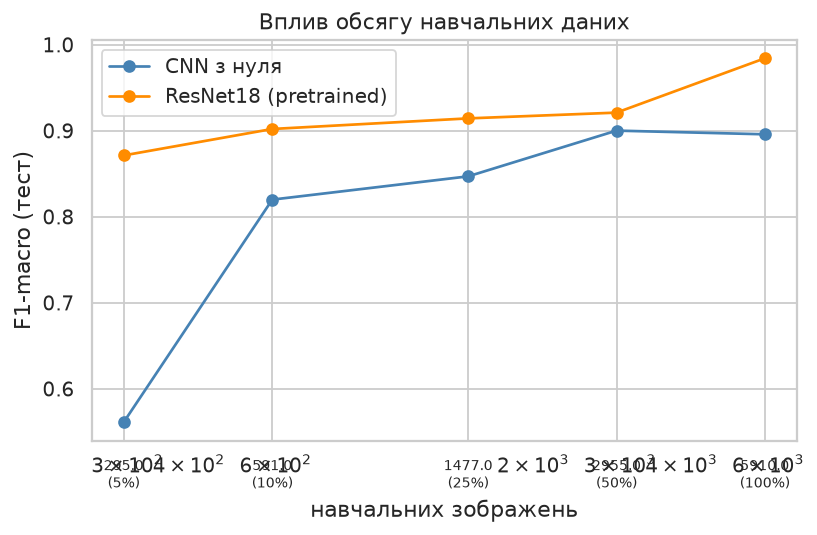

збережено assets/07-cnn-data-size.png


In [16]:
FRACTIONS = [0.05, 0.10, 0.25, 0.50, 1.00]
size_rows = []
for frac in FRACTIONS:
    if frac < 1:
        sub, _ = train_test_split(i_tr, train_size=frac, random_state=RANDOM_STATE,
                                  stratify=labels_img[i_tr])
    else:
        sub = i_tr
    for name in CNN_CLS:
        set_seed()
        m = CNN_CLS[name](len(CLASSES))
        h = fit(m, img_loader(sub, shuffle=True), va_img, epochs=CNN_EPOCHS[name],
                lr=CNN_LR[name], verbose=False)
        p = predict(m, te_img)
        size_rows.append({"частка": frac, "зображень": len(sub), "модель": name,
                          "f1_macro": f1_score(LAB_T[i_te], p, average="macro"),
                          "accuracy": accuracy_score(LAB_T[i_te], p)})
        print(f"  {frac:>5.0%} ({len(sub):>4} зобр.)  {name:<22} "
              f"F1 {size_rows[-1]['f1_macro']:.4f}")
size_res = pd.DataFrame(size_rows)
size_res.round(4).to_csv(DATA / "cnn-data-size.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
for (name, d), color in zip(size_res.groupby("модель", sort=False), ("steelblue", "darkorange")):
    ax.plot(d["зображень"], d["f1_macro"], marker="o", color=color, label=name)
ax.set_xscale("log")
ax.set_xticks(size_res["зображень"].unique())
ax.set_xticklabels([f"{n}\n({f:.0%})" for n, f in
                    size_res[["зображень", "частка"]].drop_duplicates().to_numpy()], fontsize=8)
ax.set_xlabel("навчальних зображень"); ax.set_ylabel("F1-macro (тест)")
ax.set_title("Вплив обсягу навчальних даних")
ax.legend()
save(fig, "07-cnn-data-size.png")

Чим менше даних, тим більший розрив на користь pretrained-моделі:

| Навчальних зображень | CNN з нуля | ResNet18 | Різниця |
|---|---|---|---|
| 295 (5 %) | 0.561 | 0.871 | +0.310 |
| 591 (10 %) | 0.820 | 0.902 | +0.082 |
| 1 477 (25 %) | 0.847 | 0.914 | +0.067 |
| 2 955 (50 %) | 0.900 | 0.921 | +0.021 |
| 5 910 (100 %) | 0.896 | 0.984 | +0.088 |

На 295 зображеннях (у середньому 12 на родину) CNN з нуля майже не
навчається, а ResNet18 уже дає 0.87: готові ознаки замінюють дані, яких
бракує. З ростом вибірки розрив скорочується — до 0.02 на половині даних.

Два застереження. Кожна частка — один запуск, а розкид CNN з нуля між seed
близько 0.017, тож невелике падіння з 50 % до 100 % (0.900 → 0.896) — у межах
шуму. На повних даних розрив знову зростає, бо лише там ResNet18 «перестрибує»
плато близько 0.92. Ймовірна причина — за ту саму кількість епох на меншій
вибірці мережа робить менше кроків оптимізації й до стрибка не доходить.

## 3. Нейронні мережі для класифікації текстів

### 3.1. Дані

Той самий набір, що в лабораторній № 2, з тим самим очищенням: лише записи з
оцінкою CVSS v3, без описів, що цитують власну оцінку, без оцінок VulDB у
тексті, без дублікатів; три класи по 15 000 описів. Поділ train/test теж той
самий, тож TF-IDF-модель із лабораторної № 2 — пряма точка порівняння.

In [17]:
cve = pd.read_csv(CVE_PATH, low_memory=False)
cve["v3"] = pd.to_numeric(cve["CVSS-V3"], errors="coerce")
cve = cve[cve["v3"].notna()].copy()
cve["label"] = pd.cut(cve["v3"], [-0.1, 0, 3.9, 6.9, 8.9, 10.0],
                      labels=["NONE", "LOW", "MEDIUM", "HIGH", "CRITICAL"]).astype(str)
cve["text"] = cve["DESCRIPTION"].astype(str)
cve = cve[~cve["text"].str.contains(r"Base Score|CVSS:3|CVSS ?v?3", regex=True)]
VULDB = re.compile(r"\b(classified|declared|rated|identified|marked)\s+as\s+"
                   r"(critical|problematic|easy|difficult|high|medium|low)\b", re.I)
cve["text"] = cve["text"].str.replace(VULDB, r"\1", regex=True)
cve = cve[~(cve.groupby("text")["label"].transform("nunique") > 1)].drop_duplicates("text")
TCLASSES = ["MEDIUM", "HIGH", "CRITICAL"]
cve = cve[cve["label"].isin(TCLASSES)]
cve = (cve.groupby("label", group_keys=False)
          .sample(n=15_000, random_state=RANDOM_STATE).reset_index(drop=True))
print("Розподіл класів:", dict(cve["label"].value_counts()))

tx_tr_full, tx_te, ty_tr_full, ty_te = train_test_split(
    cve["text"], cve["label"], test_size=0.25, random_state=RANDOM_STATE, stratify=cve["label"])
tx_tr, tx_va, ty_tr, ty_va = train_test_split(
    tx_tr_full, ty_tr_full, test_size=0.15, random_state=RANDOM_STATE, stratify=ty_tr_full)
print(f"train {len(tx_tr)}, validation {len(tx_va)}, test {len(tx_te)}")

# Точка порівняння — модель із лабораторної № 2 на тих самих train і test
stop = set(ENGLISH_STOP_WORDS)
clean = lambda t: " ".join(w for w in re.findall(r"[a-z][a-z]+", t.lower()) if w not in stop)
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9, sublinear_tf=True)
svm_txt = LinearSVC(C=0.5).fit(tfidf.fit_transform(tx_tr_full.map(clean)), ty_tr_full)
p = svm_txt.predict(tfidf.transform(tx_te.map(clean)))
TFIDF_F1 = f1_score(ty_te, p, average="macro")
print(f"TF-IDF + Linear SVM (лабораторна № 2): F1-macro = {TFIDF_F1:.4f}")

Розподіл класів: {'CRITICAL': np.int64(15000), 'HIGH': np.int64(15000), 'MEDIUM': np.int64(15000)}
train 28687, validation 5063, test 11250


TF-IDF + Linear SVM (лабораторна № 2): F1-macro = 0.7009


### 3.2. Токенізація, словник, індекси, padding

Для рекурентної мережі порядок слів важливий, тож стоп-слова тут **не**
прибираються («allows *an unauthenticated* attacker» і «*requires an
authenticated* user» відрізняються саме службовими словами). Токени — слова
з латинських літер у нижньому регістрі. Словник будується лише на
навчальній вибірці; слова, що трапилися менше двох разів, замінюються на
`<unk>`. Послідовності обрізаються або доповнюються `<pad>` до однакової
довжини.

In [18]:
tokenize = lambda t: re.findall(r"[a-z]+", t.lower())
tok_tr = [tokenize(t) for t in tx_tr]
freq = Counter(w for doc in tok_tr for w in doc)
itos = ["<pad>", "<unk>"] + [w for w, c in freq.most_common() if c >= 2]
stoi = {w: i for i, w in enumerate(itos)}
lens = np.array([len(d) for d in tok_tr])
MAX_LEN = int(np.ceil(np.percentile(lens, 95) / 10) * 10)
print(f"Словник: {len(itos):,} токенів (зі {len(freq):,} різних слів у train)")
print(f"Довжина описів у токенах: медіана {np.median(lens):.0f}, 95-й перцентиль "
      f"{np.percentile(lens, 95):.0f} → MAX_LEN = {MAX_LEN} "
      f"(обрізано {np.mean(lens > MAX_LEN):.1%} описів)")


def encode(texts):
    ids = np.zeros((len(texts), MAX_LEN), dtype=np.int64)
    lengths = np.zeros(len(texts), dtype=np.int64)
    for i, t in enumerate(texts):
        seq = [stoi.get(w, 1) for w in tokenize(t)][:MAX_LEN] or [1]
        ids[i, :len(seq)] = seq
        lengths[i] = len(seq)
    return torch.tensor(ids), torch.tensor(lengths)


lab_id = {c: i for i, c in enumerate(TCLASSES)}
enc = {k: encode(list(v)) for k, v in (("tr", tx_tr), ("va", tx_va), ("te", tx_te))}
lab = {k: torch.tensor([lab_id[c] for c in v]) for k, v in (("tr", ty_tr), ("va", ty_va), ("te", ty_te))}
unk = (enc["tr"][0] == 1).sum().item() / enc["tr"][1].sum().item()
print(f"Частка <unk> серед токенів train: {unk:.2%}")
ex = tx_tr.iloc[0]
print("\nПриклад:", ex[:150])
print("токени:", tokenize(ex)[:12])
print("індекси:", enc["tr"][0][0][:12].tolist())


def text_loader(k, shuffle=False, bs=128):
    return DataLoader(TensorDataset(enc[k][0], enc[k][1], lab[k]), batch_size=bs, shuffle=shuffle)

Словник: 18,412 токенів (зі 35,603 різних слів у train)
Довжина описів у токенах: медіана 36, 95-й перцентиль 101 → MAX_LEN = 110 (обрізано 3.9% описів)


Частка <unk> серед токенів train: 1.33%

Приклад: In the Linux kernel, the following vulnerability has been resolved: USB: usbtmc: prevent kernel-usb-infoleak The syzbot reported a kernel-usb-infoleak
токени: ['in', 'the', 'linux', 'kernel', 'the', 'following', 'vulnerability', 'has', 'been', 'resolved', 'usb', 'usbtmc']
індекси: [5, 2, 155, 117, 2, 233, 8, 33, 49, 333, 799, 13129]


Словник — 18 412 токенів. Довжину послідовностей обрано за 95-м перцентилем
(110 токенів): обрізається лише 3.9 % описів, а padding до найдовшого опису
лише витрачав би час на порожні кроки.

### 3.3. Pretrained embeddings: GloVe

Вектори GloVe (Wikipedia 2014 + Gigaword 5, 400 тис. слів, розмірність 100).
Для кожного слова словника, що є в GloVe, беремо готовий вектор; решту
ініціалізуємо випадково з тим самим розкидом, що й вектори GloVe.

In [19]:
EMB = 100
glove = {}
with gzip.open(GLOVE_PATH, "rt", encoding="utf-8") as fh:
    for line in fh:
        w, *vec = line.rstrip().split(" ")
        if len(vec) != EMB:                    # рядок-заголовок формату word2vec
            continue
        if w in stoi:
            glove[w] = np.asarray(vec, dtype=np.float32)
gvecs = np.stack(list(glove.values()))
rng = np.random.default_rng(RANDOM_STATE)
glove_matrix = rng.normal(0, gvecs.std(), (len(itos), EMB)).astype(np.float32)
for w, v in glove.items():
    glove_matrix[stoi[w]] = v
glove_matrix[0] = 0
tok_cov = sum(c for w, c in freq.items() if w in glove) / sum(freq.values())
print(f"Слів словника, знайдених у GloVe: {len(glove):,} з {len(itos) - 2:,} "
      f"({len(glove) / (len(itos) - 2):.1%}); покриття токенів train: {tok_cov:.1%}")
missing = [w for w, _ in freq.most_common() if w not in glove and w in stoi][:25]
print("Найчастіші слова, яких немає в GloVe:", ", ".join(missing))

Слів словника, знайдених у GloVe: 11,423 з 18,410 (62.0%); покриття токенів train: 95.4%
Найчастіші слова, яких немає в GloVe: csrf, dereference, sourcecodester, woocommerce, androidversions, scalance, deserialization, tensorflow, ipados, elementor, apq, shortcode, syscall, ssrf, ioctl, ruggedcom, simatic, totolink, tvos, gitlab, watchos, alloc, goform, phpgurukul, hardcoded


GloVe покриває 95.4 % токенів, але лише 62 % словника. Не вистачає саме
найважливіших для задачі слів: *csrf*, *ssrf*, *deserialization*,
*dereference*, *ioctl*, *syscall*, *hardcoded*, а також назв продуктів
(*woocommerce*, *gitlab*, *elementor*, *simatic*). GloVe навчено на Вікіпедії й
новинах 2014 року, де цієї технічної лексики майже немає. Отже, для
найінформативніших слів pretrained-вектори не допоможуть у принципі: вони
ініціалізуються випадково, як і в першому варіанті.

### 3.4. Модель і навчання

Embedding (100) → двонаправлений LSTM (128 у кожному напрямку) → конкатенація
усередненого й максимального виходу за всіма кроками → dropout → лінійний
шар на 3 класи. Послідовності передаються як `PackedSequence`, тож LSTM не
обробляє символи `<pad>`.

Кожен варіант навчено з **трьома різними seed**: від seed залежать
ініціалізація та порядок батчів, і розкид між запусками — пряма міра
стабільності навчання.

In [20]:
class BiLSTM(nn.Module):
    def __init__(self, vocab, emb=EMB, hidden=128, n_classes=3, weights=None):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        if weights is not None:
            self.emb.weight.data.copy_(torch.from_numpy(weights))
        self.lstm = nn.LSTM(emb, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(4 * hidden, n_classes)

    def forward(self, ids, lengths):
        packed = pack_padded_sequence(self.emb(ids), lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=ids.size(1))
        mask = (ids != 0).unsqueeze(-1)
        mean = (out * mask).sum(1) / mask.sum(1)
        mx = out.masked_fill(~mask, -1e9).max(1).values
        return self.fc(self.drop(torch.cat([mean, mx], dim=1)))


SEEDS = [42, 7, 2026]
RNN_EPOCHS = 15
va_txt, te_txt = text_loader("va"), text_loader("te")
rnn_hist, rnn_rows = {}, []
for name, weights in (("випадкові ембединги", None), ("GloVe", glove_matrix)):
    for seed in SEEDS:
        set_seed(seed)
        m = BiLSTM(len(itos), weights=weights)
        print(f"{name}, seed {seed}:")
        h = fit(m, text_loader("tr", shuffle=True), va_txt, epochs=RNN_EPOCHS, lr=2e-3,
                verbose=(seed == SEEDS[0]))
        p = predict(m, te_txt)
        rnn_hist[(name, seed)] = h
        rnn_rows.append({"ембединги": name, "seed": seed, "найкраща епоха": h["best_epoch"],
                         "мін. val loss": min(h["val_loss"]),
                         "accuracy": accuracy_score(lab["te"], p),
                         "f1_macro": f1_score(lab["te"], p, average="macro"),
                         "с/епоха": float(np.mean(h["sec"]))})
        print(f"  → тест: F1 {rnn_rows[-1]['f1_macro']:.4f}, найкраща епоха {h['best_epoch']}")
rnn_res = pd.DataFrame(rnn_rows)
rnn_res.round(4).to_csv(DATA / "rnn-results.csv", index=False)
print()
print(rnn_res.round(4).to_string(index=False))

випадкові ембединги, seed 42:


  епоха   1: train 0.8232  val 0.7555  val F1 0.6432  (7.1 с)


  епоха   2: train 0.6734  val 0.6914  val F1 0.6972  (8.0 с)


  епоха   3: train 0.5907  val 0.7122  val F1 0.6923  (8.0 с)


  епоха   4: train 0.5073  val 0.7086  val F1 0.6996  (7.1 с)


...

  епоха  14: train 0.0676  val 2.2725  val F1 0.6487  (7.1 с)


  епоха  15: train 0.0645  val 2.1323  val F1 0.6540  (6.9 с)


  → тест: F1 0.6901, найкраща епоха 2
GloVe, seed 7:


  → тест: F1 0.6681, найкраща епоха 2
GloVe, seed 2026:


  → тест: F1 0.6904, найкраща епоха 2

          ембединги  seed  найкраща епоха  мін. val loss  accuracy  f1_macro  с/епоха
випадкові ембединги    42               2         0.6914    0.6928    0.6911   7.2537
випадкові ембединги     7               2         0.7087    0.6830    0.6661   7.7596
випадкові ембединги  2026               3         0.6963    0.6948    0.6922   7.4383
              GloVe    42               2         0.6952    0.6892    0.6901   7.2933
              GloVe     7               2         0.7050    0.6814    0.6681   6.9014
              GloVe  2026               2         0.6970    0.6881    0.6904   5.9907


                     f1_mean  f1_std  best_epoch_mean  min_val_loss  sec_per_epoch
ембединги                                                                         
випадкові ембединги   0.6831  0.0148           2.3333        0.6988         7.4839
GloVe                 0.6829  0.0128           2.0000        0.6990         6.7285

Для порівняння, TF-IDF + Linear SVM: F1-macro = 0.7009


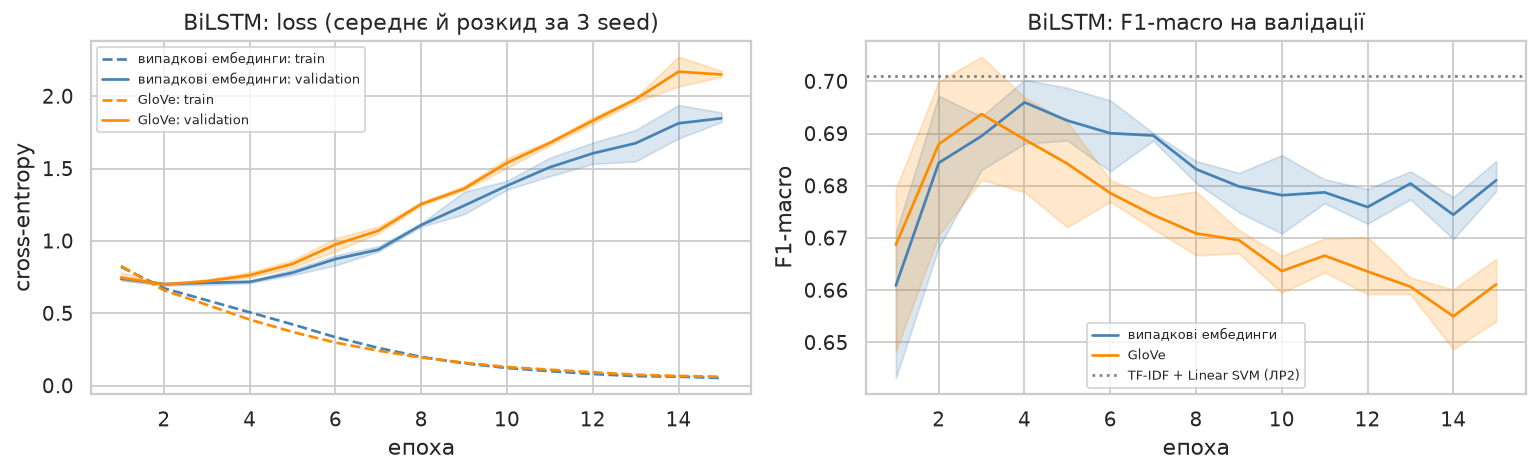

збережено assets/08-rnn-curves.png


In [21]:
summary = (rnn_res.groupby("ембединги", sort=False)
           .agg(f1_mean=("f1_macro", "mean"), f1_std=("f1_macro", "std"),
                best_epoch_mean=("найкраща епоха", "mean"), min_val_loss=("мін. val loss", "mean"),
                sec_per_epoch=("с/епоха", "mean")))
print(summary.round(4).to_string())
print(f"\nДля порівняння, TF-IDF + Linear SVM: F1-macro = {TFIDF_F1:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for name, color in (("випадкові ембединги", "steelblue"), ("GloVe", "darkorange")):
    tr = np.array([rnn_hist[(name, s)]["train_loss"] for s in SEEDS])
    va = np.array([rnn_hist[(name, s)]["val_loss"] for s in SEEDS])
    f1v = np.array([rnn_hist[(name, s)]["val_f1"] for s in SEEDS])
    ep = np.arange(1, RNN_EPOCHS + 1)
    axes[0].plot(ep, tr.mean(0), color=color, ls="--", label=f"{name}: train")
    axes[0].plot(ep, va.mean(0), color=color, label=f"{name}: validation")
    axes[0].fill_between(ep, va.min(0), va.max(0), color=color, alpha=.2)
    axes[1].plot(ep, f1v.mean(0), color=color, label=name)
    axes[1].fill_between(ep, f1v.min(0), f1v.max(0), color=color, alpha=.2)
axes[1].axhline(TFIDF_F1, color="grey", ls=":", label="TF-IDF + Linear SVM (ЛР2)")
axes[0].set_title("BiLSTM: loss (середнє й розкид за 3 seed)")
axes[1].set_title("BiLSTM: F1-macro на валідації")
axes[0].set_ylabel("cross-entropy"); axes[1].set_ylabel("F1-macro")
for ax in axes:
    ax.set_xlabel("епоха"); ax.legend(fontsize=7)
fig.tight_layout()
save(fig, "08-rnn-curves.png")

**Якість.** На повних даних різниці немає зовсім: 0.6831 ± 0.0148 з
випадковими ембедингами проти 0.6829 ± 0.0128 з GloVe. Вплив seed більший за
вплив ембедингів: запуск із seed 7 гірший на 0.02–0.03 **в обох** варіантах.

**Швидкість і стабільність.** Обидві моделі перенавчаються дуже швидко:
валідаційний loss мінімальний уже на 2–3-й епосі, а далі зростає майже втричі,
тоді як навчальний падає до 0.05. GloVe виходить на пік трохи раніше (у
середньому на 2-й епосі проти 2.3), але й деградує швидше: вектори GloVe
змістовні з першого кроку, тож мережа швидше починає підганятися під
навчальну вибірку. Час епохи в обох варіантів однаковий — ембединги впливають
на ініціалізацію, а не на обчислення.

**Порівняння з TF-IDF.** Обидві BiLSTM поступаються лінійній моделі на TF-IDF
з лабораторної № 2 (0.7009). Описи CVE короткі (медіана 36 токенів) і
шаблонні, а критичність визначається передусім **наявністю** певних слів
(«unauthenticated», «sql injection», «local»), а не їхнім порядком. Для такої
задачі перевага рекурентної мережі — вміння враховувати порядок — майже не
потрібна, а схильність до перенавчання лишається.

### 3.5. Коли pretrained embeddings допомагають: вплив обсягу даних

Pretrained embeddings зазвичай найкорисніші, коли розмічених даних мало й
мережа не встигає навчити власні вектори. Тож обидва варіанти навчено ще й на
2–25 % навчальної вибірки (по три seed на кожну частку).

    2% (  573 описів): GloVe 0.5207, випадкові ембединги 0.4995


    5% ( 1434 описів): GloVe 0.5717, випадкові ембединги 0.5609


   10% ( 2868 описів): GloVe 0.6010, випадкові ембединги 0.5973


   25% ( 7171 описів): GloVe 0.6421, випадкові ембединги 0.6341

                         mean                         std        
ембединги випадкові ембединги   GloVe випадкові ембединги   GloVe
описів                                                           
28687                  0.6831  0.6829              0.0148  0.0128
573                    0.4995  0.5207              0.0117  0.0129
1434                   0.5609  0.5717              0.0177  0.0057
2868                   0.5973  0.6010              0.0057  0.0050
7171                   0.6341  0.6421              0.0103  0.0113


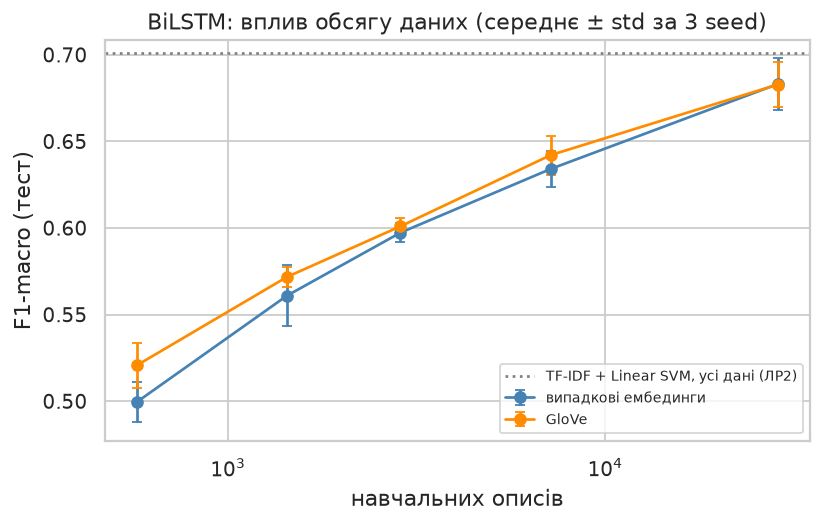

збережено assets/09-rnn-data-size.png


In [22]:
TXT_FRACS = [0.02, 0.05, 0.10, 0.25]
tsize_rows = [{"частка": 1.0, "описів": len(tx_tr), "ембединги": r["ембединги"],
               "seed": r["seed"], "f1_macro": r["f1_macro"]} for r in rnn_rows]
for frac in TXT_FRACS:
    sub, _ = train_test_split(np.arange(len(tx_tr)), train_size=frac,
                              random_state=RANDOM_STATE, stratify=lab["tr"].numpy())
    sub_loader = DataLoader(TensorDataset(enc["tr"][0][sub], enc["tr"][1][sub], lab["tr"][sub]),
                            batch_size=128, shuffle=True)
    for name, weights in (("випадкові ембединги", None), ("GloVe", glove_matrix)):
        for seed in SEEDS:
            set_seed(seed)
            m = BiLSTM(len(itos), weights=weights)
            fit(m, sub_loader, va_txt, epochs=RNN_EPOCHS, lr=2e-3, verbose=False)
            p = predict(m, te_txt)
            tsize_rows.append({"частка": frac, "описів": len(sub), "ембединги": name,
                               "seed": seed, "f1_macro": f1_score(lab["te"], p, average="macro")})
    last = pd.DataFrame(tsize_rows[-6:]).groupby("ембединги")["f1_macro"].mean()
    print(f"  {frac:>4.0%} ({len(sub):>5} описів): " +
          ", ".join(f"{k} {v:.4f}" for k, v in last.items()))
tsize = pd.DataFrame(tsize_rows)
tsize.round(4).to_csv(DATA / "rnn-data-size.csv", index=False)
tsum = tsize.groupby(["описів", "ембединги"], sort=False)["f1_macro"].agg(["mean", "std"]).unstack()
print()
print(tsum.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
for name, color in (("випадкові ембединги", "steelblue"), ("GloVe", "darkorange")):
    d = tsize[tsize["ембединги"] == name].groupby("описів")["f1_macro"].agg(["mean", "std"])
    ax.errorbar(d.index, d["mean"], yerr=d["std"], marker="o", capsize=3, color=color, label=name)
ax.axhline(TFIDF_F1, color="grey", ls=":", label="TF-IDF + Linear SVM, усі дані (ЛР2)")
ax.set_xscale("log")
ax.set_xlabel("навчальних описів"); ax.set_ylabel("F1-macro (тест)")
ax.set_title("BiLSTM: вплив обсягу даних (середнє ± std за 3 seed)")
ax.legend(fontsize=8)
save(fig, "09-rnn-data-size.png")

На малих вибірках GloVe дає невелику, але послідовну перевагу:

| Навчальних описів | Випадкові | GloVe | Різниця |
|---|---|---|---|
| 573 (2 %) | 0.500 | 0.521 | +0.021 |
| 1 434 (5 %) | 0.561 | 0.572 | +0.011 |
| 2 868 (10 %) | 0.597 | 0.601 | +0.004 |
| 7 171 (25 %) | 0.634 | 0.642 | +0.008 |
| 28 687 (100 %) | 0.683 | 0.683 | 0.000 |

Це очікувана поведінка pretrained embeddings: вони корисні, поки даних замало,
щоб мережа навчила власні вектори, і втрачають сенс, щойно даних достатньо.
Тут ефект слабший, ніж для зображень, бо GloVe не знає ключової лексики
предметної області.

## Висновки

1. **MLP на табличних даних** (F1 = 0.981) не перевершує класичних
   алгоритмів: він на рівні SVM і поступається AdaBoost (0.9905) та Random
   Forest (0.9881). Без регуляризації перенавчання видно в loss з 6-ї епохи, але
   не в F1: мережа стає надмірно впевненою, не змінюючи рішень.
2. **Pretrained CNN** переважає CNN з нуля за всіма критеріями: якість
   (F1 0.983 ± 0.001 проти 0.906 ± 0.017), швидкість збіжності (F1 = 0.91 після
   першої епохи проти 0.48) і стабільність. Найбільший виграш — на малих
   даних: на 295 зображеннях 0.87 проти 0.56. Ознаки ImageNet переносяться
   навіть на зображення бінарних файлів. Майже всі залишкові помилки — між
   варіантами однієї родини шкідливого ПЗ.
3. **GloVe для текстів CVE** на повних даних нічого не дає (0.683 в обох
   варіантах), а на малих — дає невелику перевагу (+0.02 на 573 описах). GloVe
   не знає ключових термінів безпеки (*csrf*, *deserialization*, *ssrf*).
   Обидві BiLSTM поступаються TF-IDF з лабораторної № 2: для коротких
   шаблонних описів важить наявність слів, а не їхній порядок.
4. **Загальне.** Перенесення знань допомагає тим сильніше, чим ближчі
   вихідна й цільова задачі та чим менше власних даних. Для зображень
   загальні візуальні ознаки перенеслися добре, для текстів загальна лексика
   — погано. На структурованих даних з кількома тисячами прикладів класичні
   алгоритми лишаються сильнішими за нейромережі.

Перед навчанням прибрано 895 точних дублікатів у Malimg. Без цього та сама
картинка потрапляла б і в навчальну, і в тестову вибірку.

In [23]:
print("Файли результатів:")
for f in sorted(DATA.glob("*.csv")):
    print("  ", f)
print("Рисунки:")
for f in sorted(ASSETS.glob("*.png")):
    print("  ", f)

Файли результатів:
   data/cnn-data-size.csv
   data/cnn-results.csv
   data/cnn-seeds.csv
   data/ethereum-fraud.csv
   data/mlp-vs-classic.csv
   data/rnn-data-size.csv
   data/rnn-results.csv
Рисунки:
   assets/01-mlp-curves.png
   assets/02-mlp-vs-classic.png
   assets/03-malimg-counts.png
   assets/04-malimg-examples.png
   assets/05-cnn-curves.png
   assets/06-cnn-confusion.png
   assets/07-cnn-data-size.png
   assets/08-rnn-curves.png
   assets/09-rnn-data-size.png
